In [10]:


import os
import glob
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import gradio as gr

# Setup Device & Check GPUs
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"Using device: {device} with {num_gpus} GPUs")

Using device: cuda with 2 GPUs


In [11]:
class TinyImageNetMAE(Dataset):
    def __init__(self, base_path, transform=None):
        self.transform = transform
        search_pattern = os.path.join(base_path, '*', 'images', '*.JPEG')
        self.image_paths = glob.glob(search_pattern)
        
        if len(self.image_paths) == 0:
            raise ValueError(f"No images found at {base_path}. Check Kaggle input directory.")
        else:
            print(f"✅ Loaded {len(self.image_paths)} images successfully!")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0  # Dummy label, self-supervised

# Standard ImageNet Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

exact_train_path = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train'
dataset = TinyImageNetMAE(base_path=exact_train_path, transform=transform)

# Batch size 64 handles 32 per T4 GPU
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)

✅ Loaded 100000 images successfully!


In [12]:
class Block(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=768, depth=12, num_heads=12,
                 decoder_embed_dim=384, decoder_depth=12, decoder_num_heads=6,
                 mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.mask_ratio = mask_ratio
        self.patch_dim = in_chans * patch_size ** 2
        
        # --- ENCODER (ViT-Base) ---
        self.patch_embed = nn.Linear(self.patch_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.encoder_blocks = nn.ModuleList([Block(embed_dim, num_heads) for _ in range(depth)])
        self.encoder_norm = nn.LayerNorm(embed_dim)
        
        # --- DECODER (ViT-Small) ---
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([Block(decoder_embed_dim, decoder_num_heads) for _ in range(decoder_depth)])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, self.patch_dim)

    def patchify(self, imgs):
        p = self.patch_size
        B, C, H, W = imgs.shape
        x = imgs.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, self.num_patches, self.patch_dim)
        return x

    def unpatchify(self, x):
        p = self.patch_size
        h = w = int(math.sqrt(self.num_patches))
        B, _, _ = x.shape
        x = x.reshape(B, h, w, 3, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5).reshape(B, 3, h * p, w * p)
        return x

    def random_masking(self, x):
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        ids_keep = ids_shuffle[:, :len_keep]
        x_kept = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))
        
        mask = torch.ones([B, N], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        return x_kept, mask, ids_restore

    def forward_encoder(self, x):
        x = self.patch_embed(self.patchify(x))
        x = x + self.pos_embed[:, 1:, :] 
        x, mask, ids_restore = self.random_masking(x)
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        for blk in self.encoder_blocks: x = blk(x)
        return self.encoder_norm(x), mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.expand(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], -1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)
        x = x + self.decoder_pos_embed
        
        for blk in self.decoder_blocks: x = blk(x)
        x = self.decoder_norm(x)
        return self.decoder_pred(x)[:, 1:, :] # Return pixel preds, drop CLS

    def forward(self, imgs):
        latent, mask, ids_restore = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_restore)
        target = self.patchify(imgs)
        
        # MSE Loss strictly on masked patches
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum() 
        return loss.unsqueeze(0), pred, mask # unsqueeze silences DataParallel warnings

In [ ]:
import os
import time # Added to track epoch time

model = MaskedAutoencoder().to(device)
if num_gpus > 1:
    model = nn.DataParallel(model)

optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=0.05)
epochs = 60 # Set to 60 for the full run
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
scaler = torch.amp.GradScaler('cuda') 

save_dir = '/kaggle/working/'
best_loss = float('inf')
loss_history = []

print("🚀 Starting MAE Background Training for 60 Epochs...")
for epoch in range(epochs):
    epoch_start_time = time.time()
    model.train()
    epoch_loss = 0
    
    for i, (imgs, _) in enumerate(dataloader):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            loss, _, _ = model(imgs) 
            loss = loss.mean()
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
        # Print a clean update every 500 batches instead of using tqdm
        if (i + 1) % 500 == 0:
            print(f"   [Epoch {epoch+1}, Batch {i+1}/{len(dataloader)}] Running Loss: {epoch_loss / (i + 1):.4f}")
            
    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    epoch_duration = time.time() - epoch_start_time
    
    # Save Weights
    base_model = model.module if isinstance(model, nn.DataParallel) else model
    torch.save(base_model.state_dict(), os.path.join(save_dir, 'mae_latest.pth'))
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(base_model.state_dict(), os.path.join(save_dir, 'mae_best.pth'))
        print(f"✅ Epoch {epoch+1} Completed in {epoch_duration/60:.2f} mins | Loss: {avg_loss:.4f} | 🌟 Best Model Saved!")
    else:
        print(f"✅ Epoch {epoch+1} Completed in {epoch_duration/60:.2f} mins | Loss: {avg_loss:.4f}")
        
print("🎉 Background Training Complete!")

📊 Generating Visualizations and Metrics...


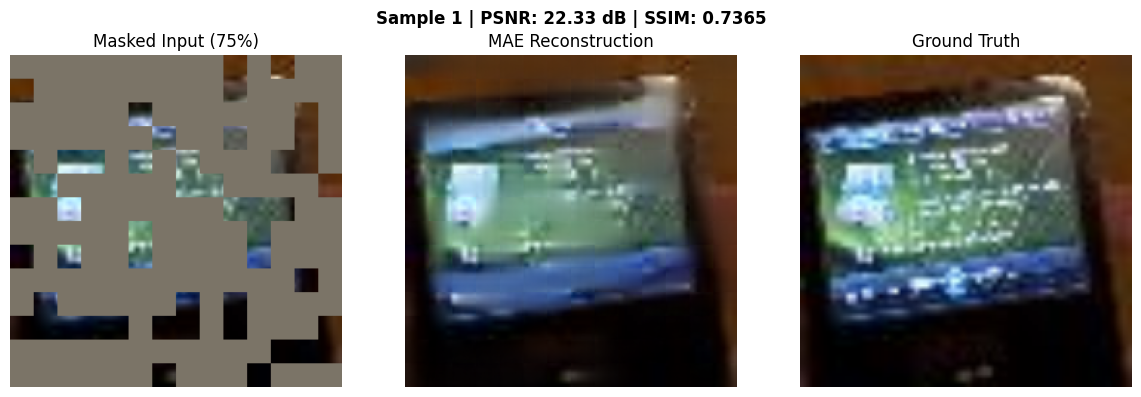

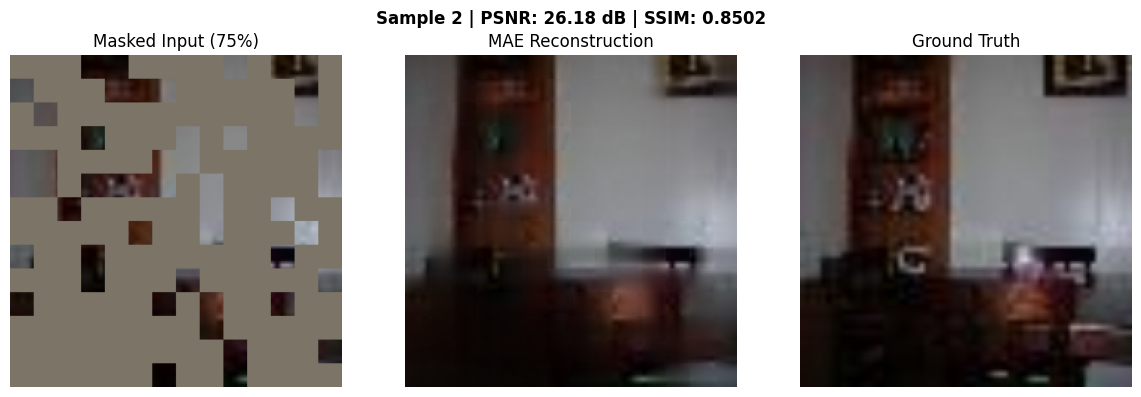

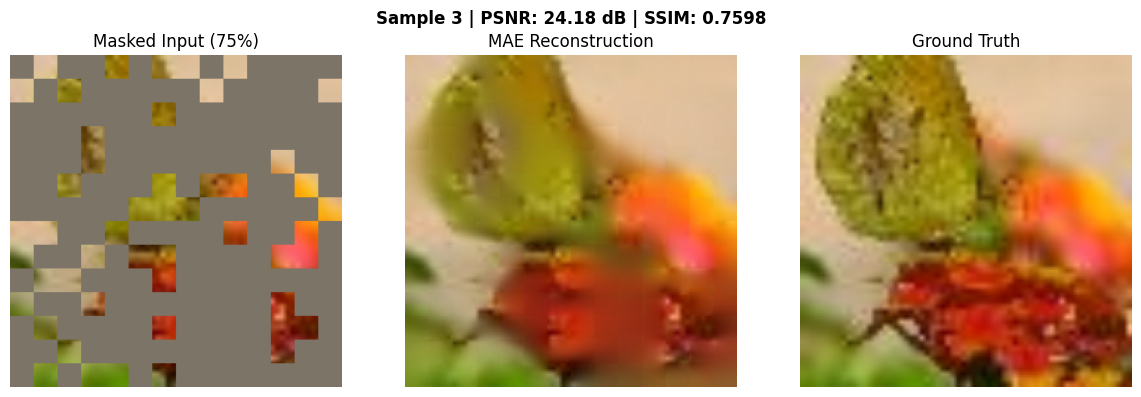

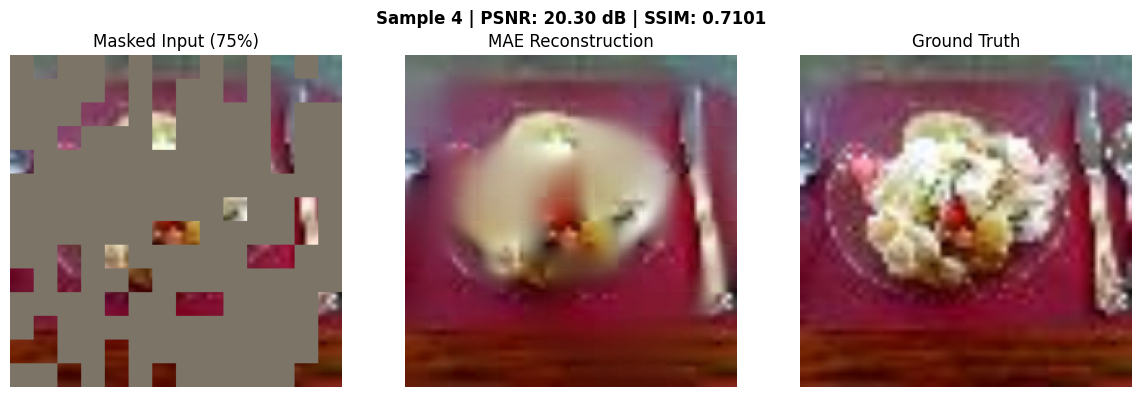

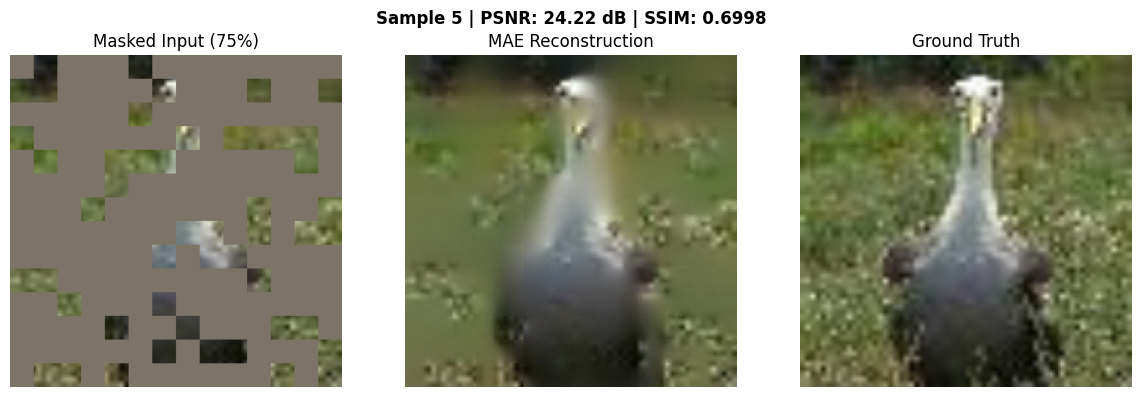

In [14]:
# --- UPDATE THIS PATH to match your actual notebook path ---
saved_weights_path = '/kaggle/input/notebooks/m1usmann/notebook0ab93a8b64/mae_best.pth'

def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(img.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(img.device)
    return img * std + mean

# 1. Load best weights for evaluation
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.load_state_dict(torch.load(saved_weights_path, map_location=device, weights_only=True))
base_model.eval()

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

samples_plotted = 0
print("📊 Generating Visualizations and Metrics...")

with torch.no_grad():
    for imgs, _ in dataloader:
        if samples_plotted >= 5: break
        imgs = imgs.to(device)
        
        target = base_model.patchify(imgs)
        _, pred, mask = base_model(imgs)
        
        mask_expanded = mask.unsqueeze(-1).repeat(1, 1, base_model.patch_dim)
        reconstruction_patches = target * (1 - mask_expanded) + pred * mask_expanded
        masked_input_patches = target * (1 - mask_expanded)
        
        original_img = base_model.unpatchify(target)
        reconstructed_img = base_model.unpatchify(reconstruction_patches)
        masked_img = base_model.unpatchify(masked_input_patches)
        
        original_img_norm = torch.clamp(unnormalize(original_img), 0, 1)
        reconstructed_img_norm = torch.clamp(unnormalize(reconstructed_img), 0, 1)
        masked_img_norm = torch.clamp(unnormalize(masked_img), 0, 1)
        
        # ✅ THE FIX: Isolate just the first image in the batch [0:1] for accurate single-image metrics
        single_recon = reconstructed_img_norm[0:1]
        single_orig = original_img_norm[0:1]
        
        psnr = psnr_metric(single_recon, single_orig)
        ssim = ssim_metric(single_recon, single_orig)
        
        # Plotting Setup
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(f"Sample {samples_plotted+1} | PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}", fontsize=12, fontweight='bold')
        
        axes[0].imshow(masked_img_norm[0].cpu().permute(1, 2, 0))
        axes[0].set_title('Masked Input (75%)')
        axes[0].axis('off')
        
        axes[1].imshow(reconstructed_img_norm[0].cpu().permute(1, 2, 0))
        axes[1].set_title('MAE Reconstruction')
        axes[1].axis('off')
        
        axes[2].imshow(original_img_norm[0].cpu().permute(1, 2, 0))
        axes[2].set_title('Ground Truth')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        samples_plotted += 1

In [15]:
def infer_app(image, mask_ratio):
    # Process user image
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    # Update masking ratio dynamically based on the slider
    base_model.mask_ratio = float(mask_ratio)
    
    with torch.no_grad():
        target = base_model.patchify(img_tensor)
        _, pred, mask = base_model(img_tensor)
        
        mask_expanded = mask.unsqueeze(-1).repeat(1, 1, base_model.patch_dim)
        
        # Combine visible ground truth patches with predicted masked patches
        reconstruction_patches = target * (1 - mask_expanded) + pred * mask_expanded
        
        # Create the visual masked input image
        masked_input_patches = target * (1 - mask_expanded)
        
        reconstructed_img = base_model.unpatchify(reconstruction_patches)
        masked_img = base_model.unpatchify(masked_input_patches)
        
        reconstructed_img_norm = torch.clamp(unnormalize(reconstructed_img), 0, 1)
        masked_img_norm = torch.clamp(unnormalize(masked_img), 0, 1)
        
    out_recon = reconstructed_img_norm[0].cpu().permute(1, 2, 0).numpy()
    out_masked = masked_img_norm[0].cpu().permute(1, 2, 0).numpy()
    
    # Reset ratio back to default after inference
    base_model.mask_ratio = 0.75 
    
    return out_masked, out_recon

# Gradio Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎨 Self-Supervised Masked Autoencoder (MAE)")
    gr.Markdown("Upload an image, adjust the mask ratio, and watch the ViT reconstruct the missing patches in real-time.")
    
    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="Upload Ground Truth Image")
            mask_slider = gr.Slider(minimum=0.1, maximum=0.9, value=0.75, step=0.05, label="Masking Ratio (Default 75%)")
            submit_btn = gr.Button("Reconstruct Image", variant="primary")
            
        with gr.Column():
            output_masked = gr.Image(label="Masked Input")
            output_recon = gr.Image(label="Model Reconstruction")
            
    submit_btn.click(fn=infer_app, inputs=[input_img, mask_slider], outputs=[output_masked, output_recon])

# share=True provides a public link you can include in your assignment submission!
demo.launch(share=True)

/tmp/ipykernel_55/270435159.py:35: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://979f1a8cf17440d442.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
